# Invalid Citation Analysis

This notebook analyzes the `invalid.csv` dataset to explore the integrity of published works, temporal trends, and differences between AI and Security venues regarding invalid or hallucinated citations.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for academic publication
sns.set_theme(style="ticks", context="paper", font_scale=1.4)
plt.style.use('seaborn-v0_8-paper') # Optional, but seaborn theme handles most
sns.set_palette("viridis")

# Additional academic formatting
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [63]:
# Load the data
file_path = 'papers_count_per_year.csv'
try:
    df = pd.read_csv(file_path, encoding='gbk')
    print(f"Successfully loaded {len(df)} records.")
except FileNotFoundError:
    print(f"File not found: {file_path}. Please ensure the notebook is in the same directory as the csv.")
    # Fallback for dev environment if needed, or error out
    df = pd.DataFrame()

total_citations = sum(df['Count'])
print(f"Total papers counted: {total_citations}")
df.head()

Successfully loaded 48 records.
Total papers counted: 56381


,Conference,Year,Count,Domain
0,AAAI,2020,1864,AI
1,AAAI,2021,1961,AI
2,AAAI,2022,1624,AI
3,AAAI,2023,2021,AI
4,AAAI,2024,2865,AI


# Paper Count By Conference

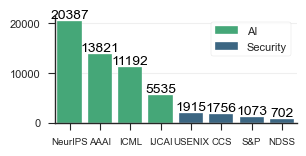

In [94]:
# Distribution by Conference
# Aggregate total counts per conference
df_conf = df.groupby(['Conference', 'Domain'], as_index=False).agg({'Count': 'sum'})
plt.figure(figsize=(3, 1.5))
# Using order to sort bars, palette viridis is set globally but can be explicit
# Order conferences by paper_count descending
order = df_conf.sort_values('Count', ascending=False)['Conference']
ax = sns.barplot(data=df_conf, x='Conference', y='Count', hue='Domain', palette='viridis_r', order=order)

ax.margins(x=0.01)
# plt.title('Distribution of Invalid Citations by Venue', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('', fontsize=14)
plt.legend()
plt.tight_layout(pad=0.36)
plt.xticks(size=7)

# Annotation loop
for p in ax.patches:
    if p.get_height() <= 0:
        continue
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()+ 1), 
                ha='center', va='bottom', fontsize=10, color='black')
    
plt.tight_layout(pad=0.36)
plt.savefig('collected_papers_by_conference.pdf', dpi=300)

## Paper Count by Year

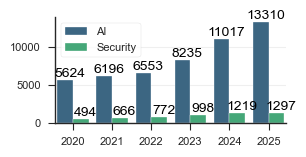

In [95]:
# Distribution by Year
# Aggregate the record with same Conference and Year
df_grouped = df.groupby(['Conference', 'Year', 'Domain'], as_index=False).agg({'Count': 'sum'})
years_sorted = sorted(df_grouped['Year'].unique())

# # 1. Separated plots for each Conference
# for conf in df_grouped['Conference'].unique():
#     subset = df_grouped[df_grouped['Conference'] == conf]
#     plt.figure(figsize=(3, 2))
    
#     # Visualize per conference
#     ax = sns.barplot(data=subset, x='Year', y='Count', order=years_sorted, palette='viridis')
#     ax.margins(x=0.01)
    
#     # Annotate bars
#     for p in ax.patches:
#         height = p.get_height()
#         if height <= 0: continue
#         ax.annotate(f'{height:.0f}', 
#                     (p.get_x() + p.get_width() / 2, height), 
#                     ha='center', va='bottom', fontsize=10)

#     #plt.title(f'Paper Count Trend: {conf}', fontsize=14)
#     plt.xlabel('', fontsize=12)
#     plt.xlabel('', fontsize=12)
#     plt.tight_layout()
#     plt.show()

# 2. Total Papers by Year (All Conferences aggregated)
df_total = df_grouped.groupby(['Year', 'Domain'], as_index=False).agg({'Count': 'sum'})

plt.figure(figsize=(3, 1.5))
ax = sns.barplot(data=df_total, x='Year', y='Count', hue='Domain', order=years_sorted, palette='viridis')
ax.margins(x=0.01)

# Annotate bars for total
for p in ax.patches:
    height = p.get_height()
    if height <= 0 or pd.isna(height): continue
    ax.annotate(f'{height:.0f}', 
                (p.get_x()+0.12 + p.get_width() / 2, height + 1), 
                ha='center', va='bottom', fontsize=10, color='black')

#plt.title('Total Paper Count by Year (All Conferences)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('', fontsize=14)
plt.legend()
plt.tight_layout(pad=0.36)
plt.savefig('collected_papers_by_year.pdf', dpi=300)